## Stellar-mass density emulator — **random-halo split** (in-distribution calibration test)

Identical to the by-box notebook, except the train/test split is over **random halos**
instead of whole boxes. Train and test now share the same boxes (same parameter sets), so
this measures *in-distribution* performance: how well the MDN captures the scatter when it
has already seen the parameter combinations.

**Why run this:** the by-box version was overconfident (68% coverage came out ~0.45).
That gap could be (a) the density head genuinely underestimating scatter, or (b) pure
generalization error to unseen parameter sets. If coverage here lands near **0.68**, the
miscalibration in the by-box run is the *generalization* term — a real statement about how
CAMELS emulators extrapolate across parameter space — not a broken model.

Features: halo mass, `t_form_10/25/50/90`, and the 35 cosmo/astro params (z=0 only).

In [2]:
import glob, os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

OUT_DIR    = '/home/jovyan/home/shmr_merger/camels_mass_history'
PARAM_FILE = ('/home/jovyan/Sims/IllustrisTNG/L50n512/SB35/'
              'CosmoAstroSeed_IllustrisTNG_L50n512_SB35.txt')
PERCENTS   = [10, 25, 50, 90]
Z0_SNAP    = 90                              # z=0 snapshot in the CAMELS catalogs

with open(PARAM_FILE) as fh:
    PARAM_KEYS = [c for c in fh.readline().lstrip('#').split()[1:] if c.lower() != 'seed']
print(f'{len(PARAM_KEYS)} parameter features')

TFORM_COLS = [f't_form_{p}' for p in PERCENTS]

torch.manual_seed(0)
np.random.seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

35 parameter features
device: cpu


### 1. Build the z=0 table (snapshot 90 only)

Read just the z=0 snapshot from each box: the selected halos, their `t_form`s, stellar
mass, and the box's cosmo/astro parameters.

In [3]:
def build_table(files, z0_snap=Z0_SNAP):
    blocks = []
    for bi, fn in enumerate(tqdm(files)):
        with h5py.File(fn, 'r') as f:
            try:
                par = {k: float(f.attrs[k]) for k in PARAM_KEYS}
            except KeyError:
                continue                                    # header missing a param

            g0 = f[f'snap_{z0_snap:03d}']
            n  = int(g0.attrs['n_halos'])
            if n == 0:
                continue

            df = pd.DataFrame({c: g0[c][:] for c in
                               ['M200c_snap', 'Mstar'] + TFORM_COLS})
            for k, v in par.items():
                df[k] = v
            df['box'] = bi
            blocks.append(df)

    out = pd.concat(blocks, ignore_index=True)
    out['logM200c'] = np.log10(out['M200c_snap'])
    out['logMstar'] = np.log10(out['Mstar'])
    return out


files = sorted(glob.glob(f'{OUT_DIR}/*_dm_mass_history.hdf5'))
print(f'{len(files)} box files')
df = build_table(files)
print('raw rows:', len(df))

1023 box files


100%|██████████| 1023/1023 [00:11<00:00, 91.71it/s]


raw rows: 4203087


/srv/conda/envs/notebook/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
FEATURES = ['logM200c'] + TFORM_COLS + PARAM_KEYS

# keep halos with stars, a real mass, valid t_forms
df = df[(df['Mstar'] > 0) & (df['M200c_snap'] > 0)].copy()
df = df.dropna(subset=FEATURES + ['logMstar'])

print(f'{len(df):,} rows from {df["box"].nunique()} boxes')
df[FEATURES + ['logMstar']].describe().T[['mean', 'std', 'min', 'max']]

4,052,699 rows from 1023 boxes


,mean,std,min,max
logM200c,11.511829,0.480484,11.000000,15.315791
t_form_10,1.883416,1.095127,0.173186,24.649198
t_form_25,3.042407,1.654404,0.232072,24.649198
t_form_50,5.012436,2.515035,0.320736,24.754040
t_form_90,9.402587,3.202435,0.349264,25.577745
Omega0,0.358048,0.100076,0.100100,0.499630
sigma8,0.798667,0.115084,0.600080,0.999830
WindEnergyIn1e51erg,4.698458,3.603560,0.901210,14.399000
RadioFeedbackFactor,1.353691,1.023597,0.250210,3.995700
VariableWindVelFactor,7.905817,3.135387,3.701300,14.789000


### 2. Split by random halos (in-distribution: train and test share boxes)

In [5]:
rng = np.random.default_rng(0)
# random-halo split: 15% of ALL rows to test, regardless of which box they came from
is_test = rng.random(len(df)) < 0.15

y = df['logMstar'].to_numpy(np.float32)
print(f'train {(~is_test).sum():,} rows   test {is_test.sum():,} rows')
print(f'boxes shared by train & test: '
      f'{len(set(df.loc[~is_test, "box"]) & set(df.loc[is_test, "box"]))} '
      f'/ {df["box"].nunique()}')

train 3,445,469 rows   test 607,230 rows
boxes shared by train & test: 1023 / 1023


### 3. HGB baseline (point estimate)

Your existing gradient-boosting emulator on the z=0 features, as the point-prediction
reference the density model is compared against.

In [6]:
X_all = df[FEATURES].to_numpy(np.float32)
hgb = HistGradientBoostingRegressor(
    max_iter=600, learning_rate=0.05, max_leaf_nodes=63,
    l2_regularization=1.0, early_stopping=True, n_iter_no_change=25,
    random_state=0)
hgb.fit(X_all[~is_test], y[~is_test])
p = hgb.predict(X_all[is_test])
r2_hgb   = r2_score(y[is_test], p)
rmse_hgb = np.sqrt(mean_squared_error(y[is_test], p))
print(f'HGB (z=0)   R2={r2_hgb:.4f}  RMSE={rmse_hgb:.4f} dex')

HGB (z=0)   R2=0.9510  RMSE=0.2175 dex


### 4. Conditional density estimator (Mixture Density Network)

A small MLP maps the features to the parameters of a `K`-component Gaussian mixture over
`log M★`. Trained on the negative log-likelihood, it learns the full conditional
distribution — the posterior mean gives the point prediction, and the spread gives the
scatter. Features and target are standardized (flows/MDNs train far better on ~N(0,1)).

In [7]:
X = df[FEATURES].to_numpy(np.float32)

# standardize using TRAIN statistics only
xm, xs = X[~is_test].mean(0), X[~is_test].std(0) + 1e-8
ym, ys = y[~is_test].mean(),  y[~is_test].std() + 1e-8
Xn = (X - xm) / xs
yn = ((y - ym) / ys).reshape(-1, 1)

Xtr = torch.tensor(Xn[~is_test], device=device)
ytr = torch.tensor(yn[~is_test], device=device)
Xte = torch.tensor(Xn[is_test],  device=device)
yte = torch.tensor(yn[is_test],  device=device)


class MDN(nn.Module):
    def __init__(self, d_in, n_comp=5, hidden=256):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(d_in, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU())
        self.pi     = nn.Linear(hidden, n_comp)
        self.mu     = nn.Linear(hidden, n_comp)
        self.logsig = nn.Linear(hidden, n_comp)

    def forward(self, x):
        h = self.body(x)
        return self.pi(h), self.mu(h), self.logsig(h).clamp(-7, 7)


def mdn_nll(pi, mu, logsig, target):
    logpi = torch.log_softmax(pi, dim=1)
    comp  = -0.5 * ((target - mu) / torch.exp(logsig))**2 - logsig - 0.5*np.log(2*np.pi)
    return -torch.logsumexp(logpi + comp, dim=1).mean()


net = MDN(X.shape[1], n_comp=5, hidden=256).to(device)
opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-5)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=15)

N, bs = Xtr.shape[0], 4096
best, best_state, bad = np.inf, None, 0
for epoch in range(300):
    net.train(); perm = torch.randperm(N, device=device)
    for i in range(0, N, bs):
        idx = perm[i:i+bs]
        opt.zero_grad()
        loss = mdn_nll(*net(Xtr[idx]), ytr[idx])
        loss.backward(); opt.step()
    net.eval()
    with torch.no_grad():
        vnll = mdn_nll(*net(Xte), yte).item()
    sched.step(vnll)
    if vnll < best - 1e-4:
        best, best_state, bad = vnll, {k: v.clone() for k, v in net.state_dict().items()}, 0
    else:
        bad += 1
    if epoch % 20 == 0 or bad == 0:
        print(f'epoch {epoch:3d}  val NLL={vnll:.4f}  (best {best:.4f})')
    if bad >= 30:
        print(f'early stop at epoch {epoch}'); break
net.load_state_dict(best_state)

epoch   0  val NLL=-0.2959  (best -0.2959)
epoch   1  val NLL=-0.3156  (best -0.3156)
epoch   2  val NLL=-0.3237  (best -0.3237)
epoch   3  val NLL=-0.3294  (best -0.3294)
epoch   4  val NLL=-0.3467  (best -0.3467)
epoch   6  val NLL=-0.3570  (best -0.3570)
epoch  12  val NLL=-0.3625  (best -0.3625)
epoch  18  val NLL=-0.3667  (best -0.3667)
epoch  20  val NLL=-0.3609  (best -0.3667)
epoch  21  val NLL=-0.3692  (best -0.3692)
epoch  40  val NLL=-0.3697  (best -0.3710)
epoch  41  val NLL=-0.3727  (best -0.3727)
epoch  45  val NLL=-0.3737  (best -0.3737)
epoch  60  val NLL=-0.3698  (best -0.3737)
epoch  62  val NLL=-0.3764  (best -0.3764)
epoch  64  val NLL=-0.3767  (best -0.3767)
epoch  68  val NLL=-0.3776  (best -0.3776)
epoch  80  val NLL=-0.3753  (best -0.3776)
epoch  89  val NLL=-0.3778  (best -0.3778)
epoch 100  val NLL=-0.3750  (best -0.3778)
early stop at epoch 119


<All keys matched successfully>

### 5. Posterior summaries: mean (→ R²), spread, and quantiles

For a Gaussian mixture the moments are closed-form, so the posterior mean and std are
exact (no sampling). We sample only for the 16/84 quantiles used in the coverage test.

In [8]:
@torch.no_grad()
def mdn_moments(x):
    """Posterior mean and std in PHYSICAL (un-standardized) log M* units."""
    pi, mu, logsig = net(x)
    w   = torch.softmax(pi, dim=1)
    sig = torch.exp(logsig)
    mean = (w * mu).sum(1)
    var  = (w * (sig**2 + mu**2)).sum(1) - mean**2
    return (mean.cpu().numpy()*ys + ym), (np.sqrt(var.cpu().numpy())*ys)


@torch.no_grad()
def mdn_sample(x, n=400):
    """Draw n samples of log M* (physical units) for each row of x."""
    pi, mu, logsig = net(x)
    w = torch.softmax(pi, dim=1)
    comp = torch.multinomial(w, n, replacement=True)              # (B, n)
    mu_s  = torch.gather(mu,             1, comp)
    sig_s = torch.gather(torch.exp(logsig), 1, comp)
    s = mu_s + sig_s * torch.randn_like(mu_s)
    return s.cpu().numpy() * ys + ym


post_mean, post_std = mdn_moments(Xte)
ytrue = y[is_test]

r2_mdn   = r2_score(ytrue, post_mean)
rmse_mdn = np.sqrt(mean_squared_error(ytrue, post_mean))
print(f'MDN posterior mean   R2={r2_mdn:.4f}  RMSE={rmse_mdn:.4f} dex')
print(f'(HGB baseline        R2={r2_hgb:.4f}  RMSE={rmse_hgb:.4f} dex)')

# coverage: does the 16-84% band contain the truth ~68% of the time?
samp = mdn_sample(Xte, n=400)
lo, hi = np.quantile(samp, [0.16, 0.84], axis=1)
cover = np.mean((ytrue >= lo) & (ytrue <= hi))
print(f'\n68% coverage = {cover:.3f}   (calibrated ≈ 0.68)')
print(f'median 16-84 width = {np.median(hi-lo):.3f} dex')

MDN posterior mean   R2=0.9556  RMSE=0.2072 dex
(HGB baseline        R2=0.9510  RMSE=0.2175 dex)

68% coverage = 0.673   (calibrated ≈ 0.68)
median 16-84 width = 0.322 dex


### 6. Is the scatter right — and is it calibrated at every halo mass?

Left: the predicted posterior spread vs the actual residual scatter, per mass bin (they
should track each other if the model is honest). Right: coverage per mass bin (should sit
on the dashed 0.68 line everywhere, not just on average).

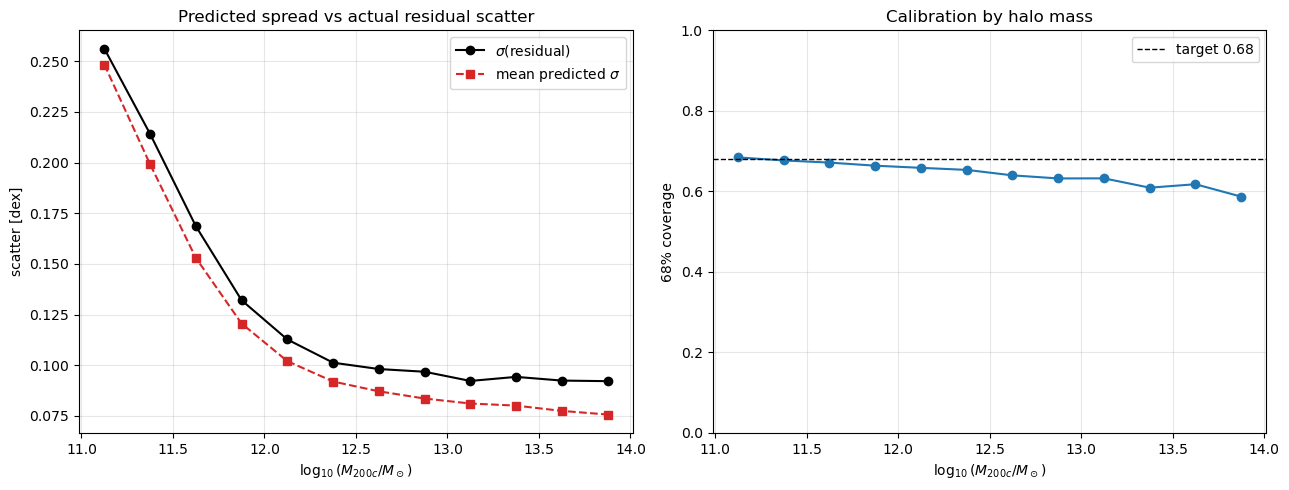

In [9]:
logM_te = df.loc[is_test, 'logM200c'].to_numpy()
resid   = post_mean - ytrue
in_band = (ytrue >= lo) & (ytrue <= hi)

bins    = np.arange(11.0, 14.25, 0.25)
centers = 0.5 * (bins[:-1] + bins[1:])
std_resid, std_pred, cov_bin, N = [], [], [], []
for a, b in zip(bins[:-1], bins[1:]):
    m = (logM_te >= a) & (logM_te < b)
    if m.sum() < 30:
        std_resid.append(np.nan); std_pred.append(np.nan); cov_bin.append(np.nan)
    else:
        std_resid.append(resid[m].std())
        std_pred.append(post_std[m].mean())
        cov_bin.append(in_band[m].mean())
    N.append(m.sum())
ok = np.array(N) >= 30

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(centers[ok], np.array(std_resid)[ok], 'k-o', label=r'$\sigma$(residual)')
ax[0].plot(centers[ok], np.array(std_pred)[ok],  'C3--s', label=r'mean predicted $\sigma$')
ax[0].set_xlabel(r'$\log_{10}(M_{200c}/M_\odot)$'); ax[0].set_ylabel('scatter [dex]')
ax[0].set_title('Predicted spread vs actual residual scatter'); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(centers[ok], np.array(cov_bin)[ok], 'C0-o')
ax[1].axhline(0.68, color='k', ls='--', lw=1, label='target 0.68')
ax[1].set_xlabel(r'$\log_{10}(M_{200c}/M_\odot)$'); ax[1].set_ylabel('68% coverage')
ax[1].set_ylim(0, 1); ax[1].set_title('Calibration by halo mass'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 7. SHMR with a real scatter band

Vary halo mass, hold the assembly + astro parameters at their medians, and draw the
posterior median plus the 16–84% band — the band the point emulator could never give you.

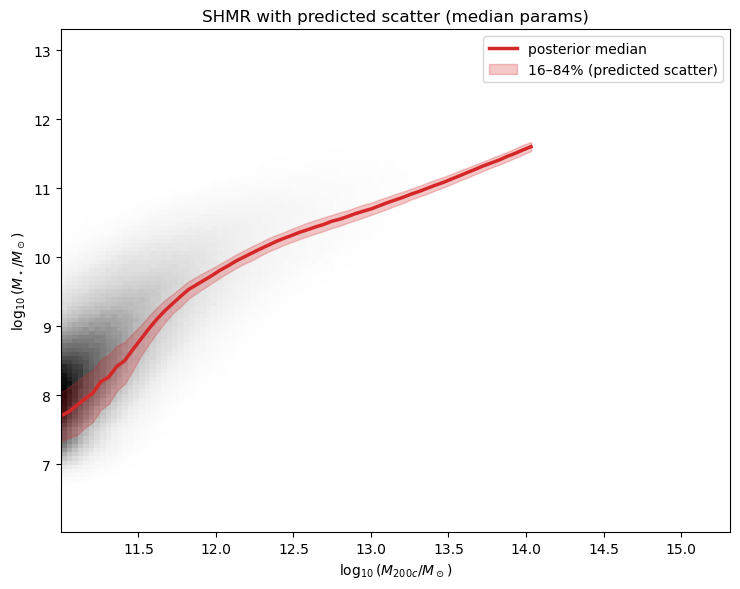

In [10]:
med = {f: float(df[f].median()) for f in FEATURES}
logMs = np.linspace(df['logM200c'].min(), df['logM200c'].quantile(0.999), 60)

rows = np.tile([med[f] for f in FEATURES], (len(logMs), 1)).astype(np.float32)
rows[:, FEATURES.index('logM200c')] = logMs
Xq = torch.tensor((rows - xm) / xs, device=device)

samp = mdn_sample(Xq, n=2000)
q16, q50, q84 = np.quantile(samp, [0.16, 0.50, 0.84], axis=1)

fig, ax = plt.subplots(figsize=(7.5, 6))
h = ax.hist2d(df['logM200c'], df['logMstar'], bins=120, cmin=1, cmap='Greys')
ax.plot(logMs, q50, 'C3-', lw=2.5, label='posterior median')
ax.fill_between(logMs, q16, q84, color='C3', alpha=0.25, label='16–84% (predicted scatter)')
ax.set_xlabel(r'$\log_{10}(M_{200c}/M_\odot)$'); ax.set_ylabel(r'$\log_{10}(M_\star/M_\odot)$')
ax.set_title('SHMR with predicted scatter (median params)'); ax.legend()
plt.tight_layout(); plt.show()

### 8. (optional) The same thing with `sbi` — a normalizing flow, like HaloFlow

If you'd rather use a flow via the exact package HaloFlow uses, this trains an amortized
NPE `q(log M★ | features)`. Set `theta` 2-D (`logM200c, logMstar`) and drop `logM200c`
from the conditions to do the *joint* `(M_h, M_*)` inference HaloFlow does literally.

In [ ]:
# pip install sbi
try:
    from sbi.inference import SNPE              # newer sbi: `from sbi.inference import NPE as SNPE`

    theta = torch.tensor(yn[~is_test])           # target = standardized log M*
    xcond = torch.tensor(Xn[~is_test])           # conditions = standardized features

    inference = SNPE(density_estimator='nsf')     # neural spline flow
    inference.append_simulations(theta, xcond)
    de = inference.train(training_batch_size=512, max_num_epochs=200)
    posterior = inference.build_posterior(de)     # amortized q(logM* | features)

    # point + coverage on a test subsample (sampling per point is slower than the MDN)
    sub = np.where(is_test)[0]
    sub = np.random.default_rng(0).choice(len(sub), size=min(3000, len(sub)), replace=False)
    Xs  = torch.tensor(Xn[is_test][sub])
    pm, c_lo, c_hi = [], [], []
    for i in range(len(Xs)):
        s = posterior.sample((300,), x=Xs[i], show_progress_bars=False).numpy().ravel()*ys + ym
        pm.append(s.mean()); q = np.quantile(s, [0.16, 0.84]); c_lo.append(q[0]); c_hi.append(q[1])
    yt = y[is_test][sub]
    print(f'sbi NPE  R2={r2_score(yt, pm):.4f}   '
          f'68% coverage={np.mean((yt>=np.array(c_lo))&(yt<=np.array(c_hi))):.3f}')
except ImportError:
    print('sbi not installed — `pip install sbi` to run this cell (the MDN above already '
          'gives you the calibrated posterior).')